# 12件の生成されたデータの分析

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from myproj.stream import iter_telemetry

project_root = Path.cwd()
if not (project_root / "pyproject.toml").is_file():
    project_root = project_root.parent

assert (project_root / "pyproject.toml").is_file()
input_path = project_root / "examples/telemetry/analysis.jsonl"

with input_path.open(encoding="utf-8") as source:
    rows = [message.to_dict() for message in iter_telemetry(source)]

df = pd.DataFrame(rows)
df["event_time"] = pd.to_datetime(df["event_time"], utc=True)

print(df)

   schema_version  device_id  sequence_no                event_time  \
0             1.0  robot-001            1 2026-10-01 00:00:00+00:00   
1             1.0  robot-001            2 2026-10-01 00:01:00+00:00   
2             1.0  robot-001            3 2026-10-01 00:02:00+00:00   
3             1.0  robot-001            4 2026-10-01 00:03:00+00:00   
4             1.0  robot-001            5 2026-10-01 00:04:00+00:00   
5             1.0  robot-001            6 2026-10-01 00:05:00+00:00   
6             1.0  robot-002            1 2026-10-01 00:00:00+00:00   
7             1.0  robot-002            2 2026-10-01 00:01:00+00:00   
8             1.0  robot-002            3 2026-10-01 00:02:00+00:00   
9             1.0  robot-002            4 2026-10-01 00:03:00+00:00   
10            1.0  robot-002            5 2026-10-01 00:04:00+00:00   
11            1.0  robot-002            6 2026-10-01 00:05:00+00:00   

   message_type  battery_percent temperature_c network_rssi status_flags  
0

In [2]:
print(df.shape)
print(df.dtypes)
print(df["battery_percent"].isna().sum())
print(df.battery_percent.isna())
print(df.battery_percent.max())
print(df.battery_percent.min())
print(df.battery_percent.mean())
print(df.battery_percent.median())

(12, 9)
schema_version                     str
device_id                          str
sequence_no                      int64
event_time         datetime64[us, UTC]
message_type                       str
battery_percent                float64
temperature_c                   object
network_rssi                    object
status_flags                    object
dtype: object
2
0     False
1     False
2     False
3      True
4     False
5     False
6     False
7     False
8     False
9     False
10     True
11    False
Name: battery_percent, dtype: bool
100.0
70.0
85.4
85.0


In [3]:
summary = df.groupby("device_id").agg(
    message_count=("battery_percent", "size"),
    battery_count=("battery_percent", "count"),
    battery_mean=("battery_percent", "mean"),
    battery_min=("battery_percent", "min"),
    battery_max=("battery_percent", "max"),
)

summary["battery_missing"] = summary["message_count"] - summary["battery_count"]

print(summary)

           message_count  battery_count  battery_mean  battery_min  \
device_id                                                            
robot-001              6              5          95.2         90.0   
robot-002              6              5          75.6         70.0   

           battery_max  battery_missing  
device_id                                
robot-001        100.0                1  
robot-002         80.0                1  


In [4]:
battery_summary = []
for device_id, group in df.groupby("device_id"):
    values = group["battery_percent"].to_numpy(dtype=float, copy=True)

    print("デバイス:", device_id)
    print("配列:", values)

    print("欠損数:", np.isnan(values).sum())
    print("通常の平均:", np.mean(values))
    print("欠損除いて平均:", np.nanmean(values))
    print("欠損を０にして平均:", np.mean(np.nan_to_num(values)))

    battery_summary.append(
        {
            "device_id": device_id,
            "missing_count": np.isnan(values).sum(),
            "mean": np.mean(values),
            "nanmean": np.nanmean(values),
            "nan_to_num_mean": np.mean(np.nan_to_num(values)),
        }
    )

デバイス: robot-001
配列: [100.  98.  96.  nan  92.  90.]
欠損数: 1
通常の平均: nan
欠損除いて平均: 95.2
欠損を０にして平均: 79.33333333333333
デバイス: robot-002
配列: [80. 78. 76. 74. nan 70.]
欠損数: 1
通常の平均: nan
欠損除いて平均: 75.6
欠損を０にして平均: 63.0


これでNumPyを使ってバッテリー欠損データ比較結果分析出来た、次はCSVに保存

In [5]:
output_path = project_root / "reports/jupyter_battery_summary.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

battery_summary_df = pd.DataFrame(battery_summary)
battery_summary_df.to_csv(output_path, encoding="utf-8", index=False)

matplotlibを使って図を作る

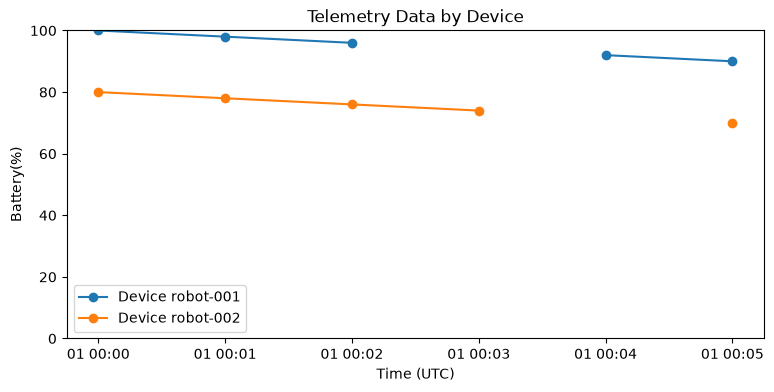

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))

for device_id, group in df.groupby("device_id"):
    ordered = group.sort_values("event_time")
    ax.plot(
        ordered["event_time"],
        ordered["battery_percent"],
        marker="o",
        label=f"Device {device_id}",
    )

ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Battery(%)")
ax.set_title("Telemetry Data by Device")
ax.legend()
ax.set_ylim(0, 100)
plt.show()

fig_path = project_root / "reports/figures/telemetry_data_by_device.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path)

In [7]:
time_df = df.set_index("event_time").sort_index()
intervals = (
    time_df.groupby("device_id")["battery_percent"]
    .resample("3min", closed="left", label="left")
    .agg(
        message_count="size",
        battery_count="count",
        battery_mean="mean",
    )
    .reset_index()
)
intervals["battery_missing"] = intervals["message_count"] - intervals["battery_count"]

print(intervals)

interval_path = project_root / "reports/battery_3min_summary.csv"
interval_path.parent.mkdir(parents=True, exist_ok=True)
intervals.to_csv(interval_path, index=False)

   device_id                event_time  message_count  battery_count  \
0  robot-001 2026-10-01 00:00:00+00:00              3              3   
1  robot-001 2026-10-01 00:03:00+00:00              3              2   
2  robot-002 2026-10-01 00:00:00+00:00              3              3   
3  robot-002 2026-10-01 00:03:00+00:00              3              2   

   battery_mean  battery_missing  
0          98.0                0  
1          91.0                1  
2          78.0                0  
3          72.0                1  


robot-001の後半3件はNaN・92・90で、有効な測定値は2件。平均は欠損を除外するため、(92 + 90) ÷ 2 = 91になる。

In [8]:
intervals_1d = (
    time_df.groupby("device_id")["battery_percent"]
    .resample("1D", closed="left", label="left")
    .agg(
        message_count="size",
        battery_count="count",
        battery_mean="mean",
        battery_min="min",
        battery_max="max",
    )
    .reset_index()
)
intervals_1d["battery_missing"] = (
    intervals_1d["message_count"] - intervals_1d["battery_count"]
)
intervals_1d["battery_missing_rate"] = (
    intervals_1d["battery_missing"] / intervals_1d["message_count"]
)
print(intervals_1d)

interval_path_1d = project_root / "reports/battery_1d_summary.csv"
interval_path_1d.parent.mkdir(parents=True, exist_ok=True)
intervals_1d.to_csv(interval_path_1d, index=False)

   device_id                event_time  message_count  battery_count  \
0  robot-001 2026-10-01 00:00:00+00:00              6              5   
1  robot-002 2026-10-01 00:00:00+00:00              6              5   

   battery_mean  battery_min  battery_max  battery_missing  \
0          95.2         90.0        100.0                1   
1          75.6         70.0         80.0                1   

   battery_missing_rate  
0              0.166667  
1              0.166667  


このレポートは2026-10-01の00:00〜00:05（UTC）のサンプルに基づく。欠損率は記録内のバッテリー未計測率で、通信のオンライン率ではない。

In [9]:
boundary_df = pd.DataFrame(
    {
        "event_time": pd.to_datetime(
            ["2026-10-01T14:59:00Z", "2026-10-01T15:00:00Z"],
            utc=True,
        ),
        "battery_percent": [90.0, 70.0],
    }
).set_index("event_time")

jp_boundary_df = (
    boundary_df["battery_percent"]
    .resample("1D")
    .agg(
        count="size",
        mean="mean",
    )
)

boundary_jst = boundary_df.tz_convert("Asia/Tokyo")
jp_boundary_jst = (
    boundary_jst["battery_percent"]
    .resample("1D")
    .agg(
        count="size",
        mean="mean",
    )
)

print(jp_boundary_df)
print(jp_boundary_jst)

                           count  mean
event_time                            
2026-10-01 00:00:00+00:00      2  80.0
                           count  mean
event_time                            
2026-10-01 00:00:00+09:00      1  90.0
2026-10-02 00:00:00+09:00      1  70.0


UTCの14:59と15:00は、日本時間では23:59と翌日00:00になる。そのため日本時間では別の日に集計される。日本時間の日次レポートでは、日付の区切りを決める前にタイムゾーンを変換する必要がある。

## 結果
- 各デバイス6件中、有効な測定値は5件ずつ、合計10件だった。
- NumPyの `np.mean` は欠損を含むと `NaN` になった。
- `np.nanmean` は欠損を除外し、平均は95.2と75.6になった。
  Pandasの `mean()` でも同じ結果になった。
- 欠損を0で補うと、平均は約79.33と63.0まで下がった。
  未計測を残量0として扱うと平均を過小評価するため、
  今回は欠損を除外して平均を求める。

欠損値をNaNのまま残しているため、未計測の時刻では点が描かれず、その前後の線も途切れる。